# MZM MLP

## Setup

In [1]:
# ==============================
# Import Required Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import re

from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
import optax
from flax import nnx

# Reproducibility
random_state = 123
np.random.seed(random_state)

d:\_Dev\envs\mzm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Definitions

In [2]:
BN_EPS = 1e-5
BN_MOMENTUM = 0.9


def _nnx_module_list(items):
    """Wrap a list of nnx submodules so it's tracked as dynamic pytree data
    rather than a static attribute, across flax.nnx versions. Newer
    flax.nnx added an `nnx.data` marker and raises "Found data ... assigned
    to static attribute" on a plain list without it; older flax.nnx has no
    `nnx.data` and handles a plain list of submodules directly, so this
    falls back to that when `nnx.data` isn't available.
    """
    return nnx.data(items) if hasattr(nnx, "data") else items


_MMOE_SHAPE_TEMPLATE = (200, 300, 350, 300, 200)  # Base MLP's default hidden_dims profile,
# reused to shape/scale MultiGateMoE's experts (both for the hyperparameter
# search below and the parameter-efficiency sweep further down).


class MLP5(nnx.Module):
    """BatchNorm here is plain math over params it only reads (never
    mutates in place), so the whole forward pass is a pure function of
    (params, batch_stats, x)."""

    def __init__(
        self, input_dim=8, output_dim=3, dropout=0.2,
        hidden_dims=(200, 300, 350, 300, 200), *, rngs: nnx.Rngs,
    ):
        he = jax.nn.initializers.he_uniform()
        zeros = jax.nn.initializers.zeros

        def linear(d_in, d_out):
            return nnx.Linear(d_in, d_out, kernel_init=he, bias_init=zeros, rngs=rngs)

        def bn_params(d):
            return (
                nnx.Param(jnp.ones((d,))),
                nnx.Param(jnp.zeros((d,))),
                nnx.BatchStat(jnp.zeros((d,))),
                nnx.BatchStat(jnp.ones((d,))),
            )

        h1, h2, h3, h4, h5 = hidden_dims

        self.fc1 = linear(input_dim, h1)
        self.bn1_scale, self.bn1_bias, self.bn1_mean, self.bn1_var = bn_params(h1)

        self.fc2 = linear(h1, h2)
        self.bn2_scale, self.bn2_bias, self.bn2_mean, self.bn2_var = bn_params(h2)

        self.fc3 = linear(h2, h3)
        self.bn3_scale, self.bn3_bias, self.bn3_mean, self.bn3_var = bn_params(h3)

        self.fc4 = linear(h3, h4)
        self.bn4_scale, self.bn4_bias, self.bn4_mean, self.bn4_var = bn_params(h4)

        self.fc5 = linear(h4, h5)
        self.bn5_scale, self.bn5_bias, self.bn5_mean, self.bn5_var = bn_params(h5)

        self.output = linear(h5, output_dim)

        self.dropout = nnx.Dropout(dropout)

    def _block(self, x, fc, scale, bias, running_mean, running_var, *, train, rngs):
        x = fc(x)
        if train:
            mean = jnp.mean(x, axis=0)
            var = jnp.var(x, axis=0)
        else:
            mean, var = running_mean[...], running_var[...]
        x = (x - mean) / jnp.sqrt(var + BN_EPS) * scale[...] + bias[...]
        x = nnx.relu(x)
        x = self.dropout(x, deterministic=not train, rngs=rngs)
        return x, (mean, var)

    def __call__(self, x, *, train: bool, rngs=None):
        residual = x

        x, s1 = self._block(x, self.fc1, self.bn1_scale, self.bn1_bias, self.bn1_mean, self.bn1_var, train=train, rngs=rngs)
        x, s2 = self._block(x, self.fc2, self.bn2_scale, self.bn2_bias, self.bn2_mean, self.bn2_var, train=train, rngs=rngs)
        x, s3 = self._block(x, self.fc3, self.bn3_scale, self.bn3_bias, self.bn3_mean, self.bn3_var, train=train, rngs=rngs)
        x, s4 = self._block(x, self.fc4, self.bn4_scale, self.bn4_bias, self.bn4_mean, self.bn4_var, train=train, rngs=rngs)
        x, s5 = self._block(x, self.fc5, self.bn5_scale, self.bn5_bias, self.bn5_mean, self.bn5_var, train=train, rngs=rngs)
        batch_stats = {
            "bn1_mean": s1[0], "bn1_var": s1[1],
            "bn2_mean": s2[0], "bn2_var": s2[1],
            "bn3_mean": s3[0], "bn3_var": s3[1],
            "bn4_mean": s4[0], "bn4_var": s4[1],
            "bn5_mean": s5[0], "bn5_var": s5[1],
        }

        if residual.shape[-1] < x.shape[-1]:
            pad = x.shape[-1] - residual.shape[-1]
            residual = jnp.pad(residual, ((0, 0), (0, pad)))
        elif residual.shape[-1] > x.shape[-1]:
            residual = residual[:, : x.shape[-1]]

        x = x + residual

        return self.output(x), batch_stats

In [3]:
class ExpertNN(nnx.Module):
    """A single soft-MoE expert: an MLP predicting all D_o outputs directly,
    using the same expand-to-peak-then-shrink hidden_dims shape as Base
    (just resized). Reuses MLP5's manual BatchNorm-as-plain-math pattern
    purely for consistency with the generic BatchStat-blending contract in
    train_model — not for jax.grad-through-input (no longer used here)."""

    def __init__(self, input_dim, output_dim, hidden_dims, dropout=0.0, *, rngs: nnx.Rngs):
        he = jax.nn.initializers.he_uniform()
        zeros = jax.nn.initializers.zeros

        def linear(d_in, d_out):
            return nnx.Linear(d_in, d_out, kernel_init=he, bias_init=zeros, rngs=rngs)

        self.n_layers = len(hidden_dims)
        prev = input_dim
        for i, h in enumerate(hidden_dims, start=1):
            setattr(self, f"fc{i}", linear(prev, h))
            setattr(self, f"bn{i}_scale", nnx.Param(jnp.ones((h,))))
            setattr(self, f"bn{i}_bias", nnx.Param(jnp.zeros((h,))))
            setattr(self, f"bn{i}_mean", nnx.BatchStat(jnp.zeros((h,))))
            setattr(self, f"bn{i}_var", nnx.BatchStat(jnp.ones((h,))))
            prev = h
        self.output = linear(prev, output_dim)
        self.dropout = nnx.Dropout(dropout)

    def _block(self, x, fc, scale, bias, running_mean, running_var, *, train, rngs):
        x = fc(x)
        if train:
            mean = jnp.mean(x, axis=0)
            var = jnp.var(x, axis=0)
        else:
            mean, var = running_mean[...], running_var[...]
        x = (x - mean) / jnp.sqrt(var + BN_EPS) * scale[...] + bias[...]
        x = nnx.relu(x)
        x = self.dropout(x, deterministic=not train, rngs=rngs)
        return x, (mean, var)

    def __call__(self, x, *, train: bool, rngs=None):
        stats = {}
        for i in range(1, self.n_layers + 1):
            x, (mean, var) = self._block(
                x, getattr(self, f"fc{i}"),
                getattr(self, f"bn{i}_scale"), getattr(self, f"bn{i}_bias"),
                getattr(self, f"bn{i}_mean"), getattr(self, f"bn{i}_var"),
                train=train, rngs=rngs,
            )
            stats[f"bn{i}_mean"] = mean
            stats[f"bn{i}_var"] = var
        return self.output(x), stats

### Multi-gate MoE (MMoE)

`MultiGateMoE` is a Mixture-of-Experts model built for this multi-task setting: `BW_3dB`, `IL` and `V_pi` are predicted jointly by a shared pool of experts, but instead of one gate whose weights are reused for every output, **each output gets its own small gating network** over that same shared expert pool (the MMoE architecture of [Ma et al., 2018](https://dl.acm.org/doi/10.1145/3219819.3220007)).

This matters here because the three targets behave differently as a function of geometry — the curve-fitting above shows `BW_3dB` and `V_pi` roughly following `1/Phase_length` while `IL` is roughly linear in `Phase_length` — so letting each target learn its own mixture of the shared experts should fit all three better than forcing them through one fixed combination. The per-task gating heads are tiny relative to the expert pool (~700 extra params on top of ~336k), so this is essentially free compared to a single-gate design.

This is the architecture compared against the Base MLP throughout the rest of the notebook.

In [4]:
class MultiGateMoE(nnx.Module):
    """Multi-gate Mixture-of-Experts (MMoE, Ma et al. 2018): `n_experts`
    always-active experts (each shaped like Base's own expand-to-peak-then-
    shrink hidden_dims profile, resized), shared across all `output_dim`
    tasks (BW_3dB, IL, V_pi). Each task gets its own small gating network
    over that same shared expert pool, instead of one gate whose weights are
    reused for every output, so each target can learn a different soft
    combination of experts. The gating heads are cheap relative to the
    expert pool, which holds almost all the parameters.
    """

    def __init__(
        self, input_dim=8, output_dim=3, n_experts=6,
        expert_hidden_dims=(80, 121, 141, 121, 80), gating_hidden=24,
        dropout=0.0, *, rngs: nnx.Rngs,
    ):
        he = jax.nn.initializers.he_uniform()
        zeros = jax.nn.initializers.zeros
        self.n_experts = n_experts
        self.output_dim = output_dim

        self.experts = _nnx_module_list([
            ExpertNN(input_dim, output_dim, expert_hidden_dims, dropout=dropout, rngs=rngs)
            for _ in range(n_experts)
        ])

        # One independent gating network per output/task, all reading the
        # same raw input features and gating the same shared expert pool.
        self.gate_fc1 = _nnx_module_list([
            nnx.Linear(input_dim, gating_hidden, kernel_init=he, bias_init=zeros, rngs=rngs)
            for _ in range(output_dim)
        ])
        self.gate_fc2 = _nnx_module_list([
            nnx.Linear(gating_hidden, n_experts, kernel_init=he, bias_init=zeros, rngs=rngs)
            for _ in range(output_dim)
        ])

    def __call__(self, x, *, train: bool, rngs=None):
        expert_outs = []
        stats = {}
        for i, expert in enumerate(self.experts):
            out_i, stats_i = expert(x, train=train, rngs=rngs)
            expert_outs.append(out_i)
            stats[i] = stats_i
        expert_outs = jnp.stack(expert_outs, axis=-1)  # (batch, D_o, n_experts)

        gate_weights = jnp.stack([
            nnx.softmax(self.gate_fc2[t](nnx.relu(self.gate_fc1[t](x))), axis=-1)
            for t in range(self.output_dim)
        ], axis=1)  # (batch, D_o, n_experts) — a separate distribution per task

        pred = jnp.einsum("boe,boe->bo", expert_outs, gate_weights)
        return pred, {"experts": stats}

## Data Loading & Preprocessing

In [5]:
# ==============================
# Load and Preprocess Data
# ==============================
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = "/content/drive/MyDrive/MZM Data/Sim_generated_dataset.txt"
file_path = "Sim_generated_dataset.txt"

In [6]:
with open(file_path) as f:
    cleaned = [re.sub(r'[\[\]]', '', line.strip()) for line in f]

df = pd.read_csv(StringIO("\n".join(cleaned)), header=None)
df.columns = [
    "PN_offset", "Bias_V", "Core_width", "P+_width", "N+_width",
    "P_width", "N_width", "Phase_length", "BW_3dB", "IL", "V_pi"
]

# Data cleaning: remove rows with extreme V_pi (>500, <0)
df_cleaned = df[(df['V_pi'] < 500) & (df['V_pi'] > 0)].copy()
print(f"Dataset size after cleaning: {len(df_cleaned)} samples")

# Split features / targets
feature_cols = df_cleaned.columns[:8]
target_cols = df_cleaned.columns[8:]

x = df_cleaned[feature_cols].values
y = df_cleaned[target_cols].values

# Train / test split
x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(
    x, y, test_size=0.1, random_state=random_state
)

# ==============================
# Scaling (fit on TRAIN only)
# ==============================
scaler_x = MinMaxScaler()  # Features
scaler_y1 = StandardScaler()  # BW_3dB
scaler_y2 = StandardScaler()  # IL
scaler_y3 = StandardScaler()  # V_pi

x_train_scaled = scaler_x.fit_transform(x_train_raw)
y_train_scaled = np.hstack([
    scaler_y1.fit_transform(y_train_raw[:, 0:1]),
    scaler_y2.fit_transform(y_train_raw[:, 1:2]),
    scaler_y3.fit_transform(y_train_raw[:, 2:3]),
])

x_test_scaled = scaler_x.transform(x_test_raw)
y_test_scaled = np.hstack([
    scaler_y1.transform(y_test_raw[:, 0:1]),
    scaler_y2.transform(y_test_raw[:, 1:2]),
    scaler_y3.transform(y_test_raw[:, 2:3]),
])

# Convert to tensors
x_train_t = jnp.asarray(x_train_scaled, dtype=jnp.float32)
y_train_t = jnp.asarray(y_train_scaled, dtype=jnp.float32)
x_test_t  = jnp.asarray(x_test_scaled, dtype=jnp.float32)
y_test_t  = jnp.asarray(y_test_scaled, dtype=jnp.float32)

print(f"Train: {x_train_t.shape[0]} | Test: {x_test_t.shape[0]}")
df_cleaned.describe()

Dataset size after cleaning: 9614 samples
Train: 8652 | Test: 962


,PN_offset,Bias_V,Core_width,P+_width,N+_width,P_width,N_width,Phase_length,BW_3dB,IL,V_pi
count,9.614000e+03,9614.000000,9.614000e+03,9.614000e+03,9.614000e+03,9.614000e+03,9.614000e+03,9614.000000,9614.000000,9614.000000,9614.000000
mean,-4.106982e-09,-5.965076,4.774007e-07,2.584718e-07,2.618829e-07,7.853203e-07,7.904345e-07,0.002285,46.011836,1.577726,33.900601
std,1.272187e-07,2.251585,2.488443e-08,1.315607e-07,1.370419e-07,1.293550e-07,1.313482e-07,0.001030,13.757979,0.896971,31.995194
min,-2.150000e-07,-10.000000,4.050720e-07,4.509540e-08,4.500550e-08,4.510390e-07,4.501570e-07,0.000500,2.256410,0.166187,3.564810
25%,-1.064180e-07,-7.874185,4.613922e-07,1.472730e-07,1.420500e-07,6.774380e-07,6.796328e-07,0.001415,34.923077,0.881409,14.321325
50%,0.000000e+00,-5.819890,4.754365e-07,2.522630e-07,2.602395e-07,7.865730e-07,7.942275e-07,0.002229,44.974359,1.394790,23.757300
75%,9.655928e-08,-4.041150,4.891833e-07,3.689188e-07,3.806483e-07,8.958177e-07,9.036680e-07,0.003167,54.800000,2.162227,41.027525
max,2.150000e-07,-2.250820,6.000000e-07,4.998190e-07,5.000000e-07,1.098400e-06,1.099670e-06,0.005971,74.000000,5.255890,394.839000


## Data Visualization

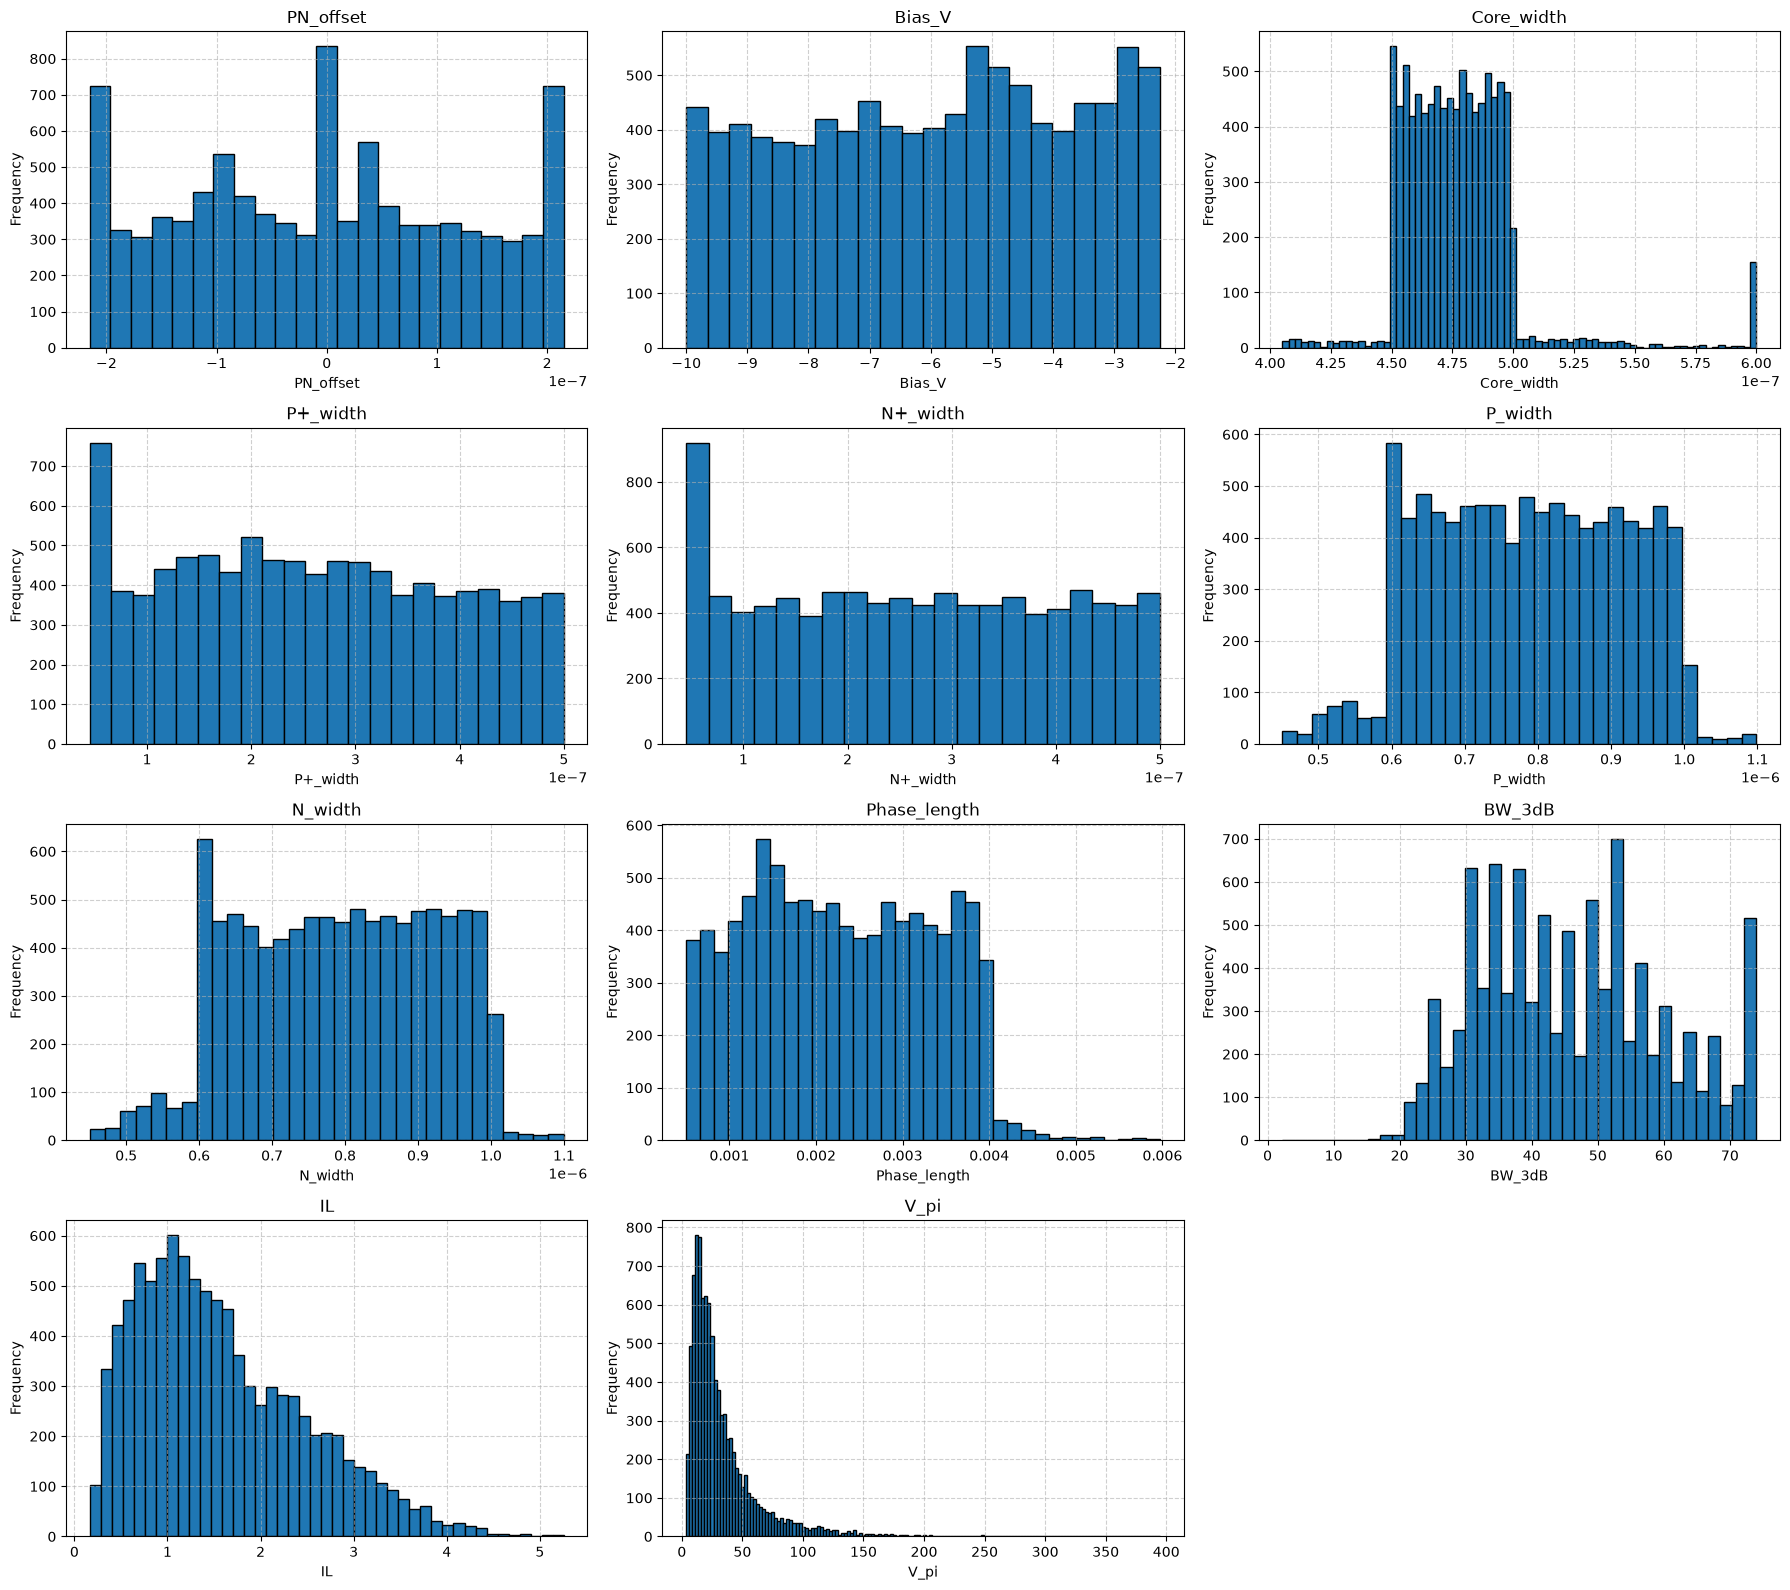

In [7]:
# Combine all columns
all_cols = list(feature_cols) + list(target_cols)
n_cols = len(all_cols)

# Define grid size
n_grid_cols = 3
n_grid_rows = 4

fig, axes = plt.subplots(
    nrows=n_grid_rows,
    ncols=n_grid_cols,
    figsize=(6 * n_grid_cols, 4 * n_grid_rows)
)

axes = axes.flatten()

for i, col in enumerate(all_cols):
    axes[i].hist(df_cleaned[col], bins='auto', edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

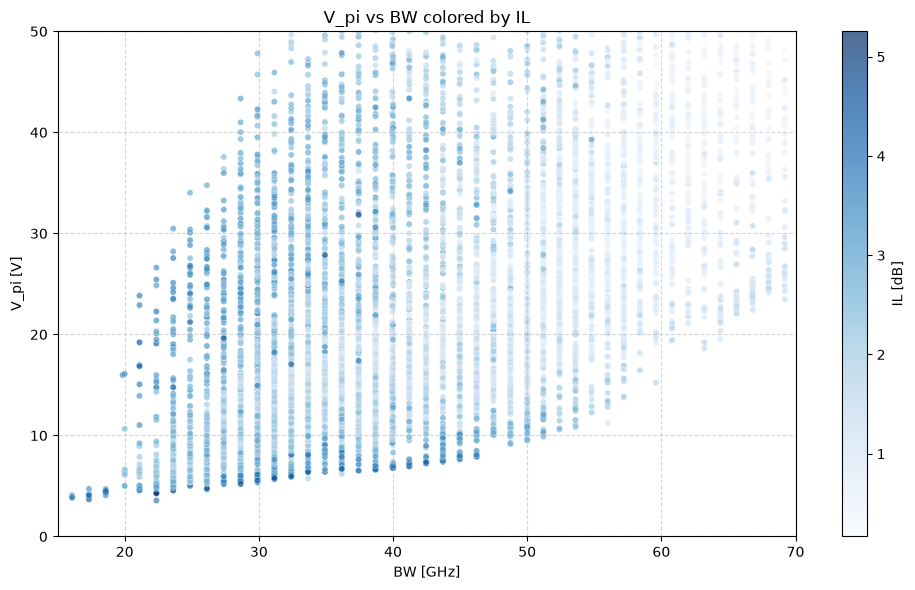

In [8]:
x = df_cleaned['BW_3dB']
y = df_cleaned['V_pi']
c = df_cleaned['IL']

plt.figure(figsize=(10,6))
sc = plt.scatter(x, y, c=c, cmap='Blues', alpha=0.7, s=20, edgecolors='w', linewidth=0.3)

plt.xlabel('BW [GHz]')
plt.ylabel('V_pi [V]')
# plt.yscale('log')
plt.title('V_pi vs BW colored by IL')

# xlim and ylim matching the paper (page #5)
plt.xlim(15, 70)
plt.ylim(0, 50)

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('IL [dB]')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

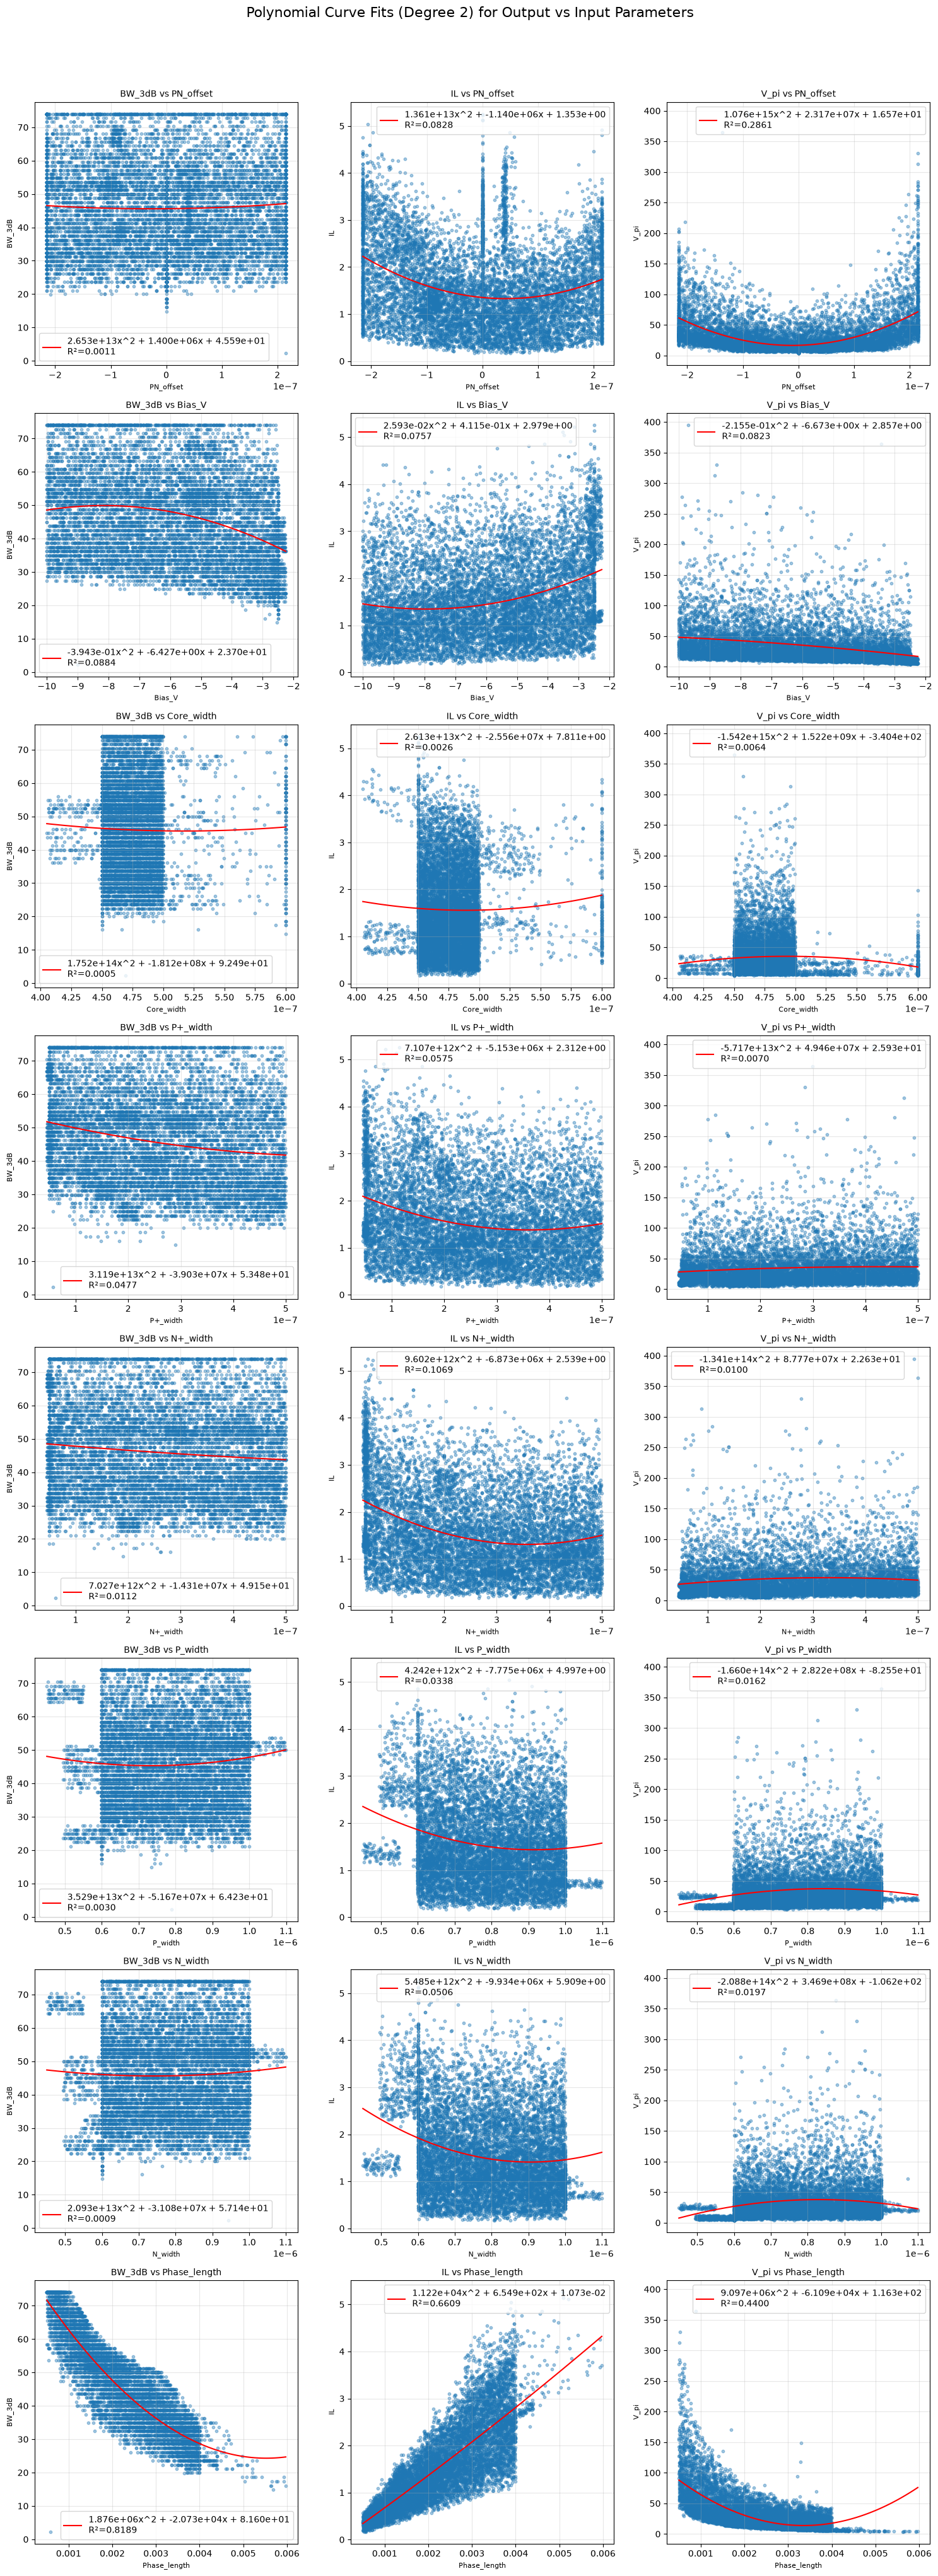

In [9]:
feature_cols = df_cleaned.columns[:8]
target_cols = df_cleaned.columns[8:]

n_features = len(feature_cols)
n_targets = len(target_cols)

fig, axes = plt.subplots(
    n_features,
    n_targets,
    figsize=(5 * n_targets, 5 * n_features)
)

for i, target_col in enumerate(target_cols):
    for j, feature_col in enumerate(feature_cols):
        ax = axes[j, i] if n_targets > 1 and n_features > 1 else (axes[j] if n_targets == 1 else axes[i])

        x_data = df_cleaned[feature_col].values
        y_data = df_cleaned[target_col].values

        # Perform polynomial curve fitting (degree=2)
        try:
            # Check for NaNs or Infs that could break polyfit
            valid_indices = ~np.isnan(x_data) & ~np.isinf(x_data) & ~np.isnan(y_data) & ~np.isinf(y_data)
            x_data_valid = x_data[valid_indices]
            y_data_valid = y_data[valid_indices]

            coeffs = np.polyfit(x_data_valid, y_data_valid, 2)
            poly = np.poly1d(coeffs)

            x_fit = np.linspace(x_data_valid.min(), x_data_valid.max(), 100)
            y_fit = poly(x_fit)

            # R² on valid points
            y_pred_valid = poly(x_data_valid)
            ss_res = np.sum((y_data_valid - y_pred_valid) ** 2)
            ss_tot = np.sum((y_data_valid - np.mean(y_data_valid)) ** 2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan

            a, b, c = coeffs
            poly_label = f"{a:.3e}x^2 + {b:.3e}x + {c:.3e}\nR²={r2:.4f}"

            ax.scatter(x_data, y_data, alpha=0.4, s=10)
            ax.plot(x_fit, y_fit, color='red', label=poly_label)
            ax.set_title(f'{target_col} vs {feature_col}', fontsize=10)
            ax.legend()

        except Exception as e:
            ax.scatter(x_data, y_data, alpha=0.4, s=10)
            ax.set_title(f'{target_col} vs {feature_col}\n(Fit Error: {e})', fontsize=10)

        ax.set_xlabel(feature_col, fontsize=8)
        ax.set_ylabel(target_col, fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Polynomial Curve Fits (Degree 2) for Output vs Input Parameters', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

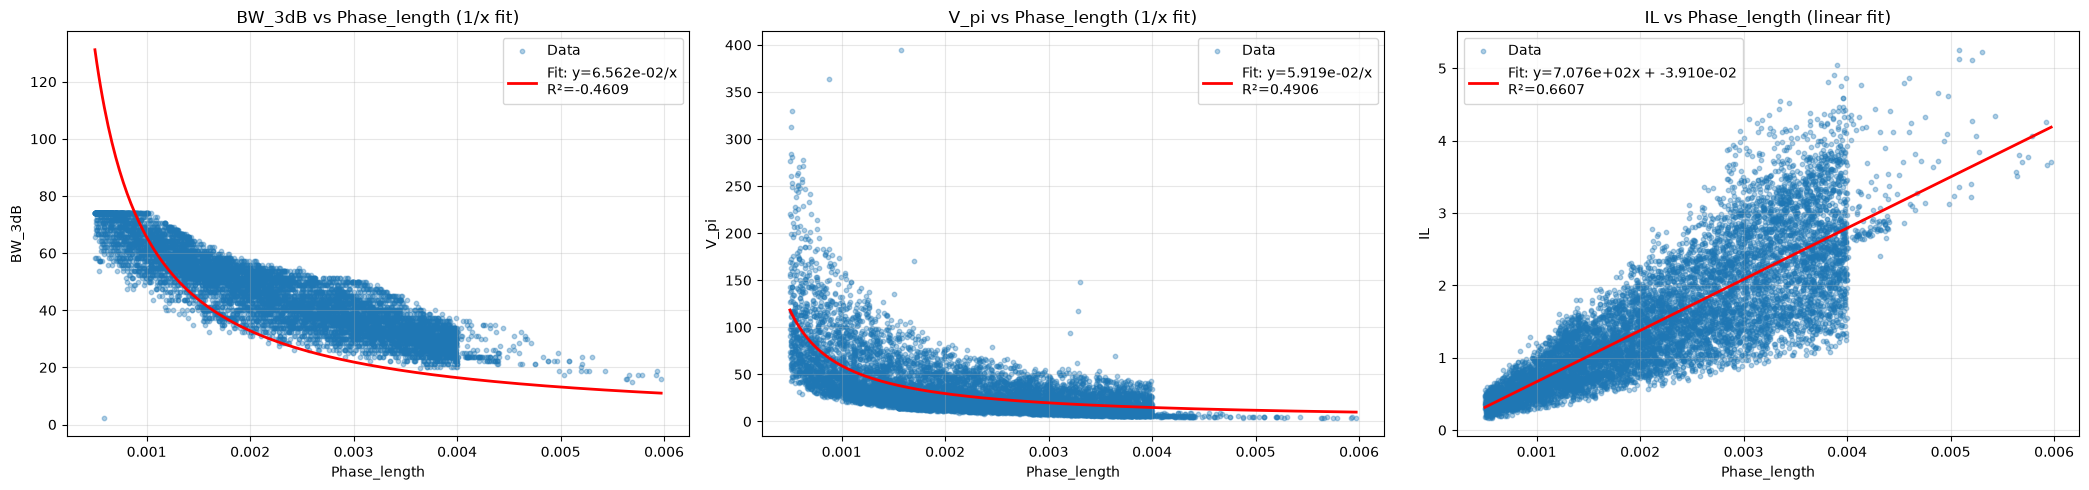

BW_3dB fit: y = 6.562042e-02/x, R^2 = -0.460919
V_pi fit:   y = 5.918740e-02/x, R^2 = 0.490553
IL fit:     y = 7.075717e+02x + -3.910009e-02, R^2 = 0.660738


In [10]:
# Fit models for:
# 1) BW_3dB vs Phase_length with y = a*(1/x)
# 2) V_pi   vs Phase_length with y = a*(1/x)
# 3) IL     vs Phase_length with y = m*x + c

phase = df_cleaned["Phase_length"].to_numpy()
bw = df_cleaned["BW_3dB"].to_numpy()
vpi = df_cleaned["V_pi"].to_numpy()
il = df_cleaned["IL"].to_numpy()

mask = (
    np.isfinite(phase) & (phase > 0) &
    np.isfinite(bw) & np.isfinite(vpi) & np.isfinite(il)
)
phase_fit = phase[mask]
bw_fit = bw[mask]
vpi_fit = vpi[mask]
il_fit = il[mask]

# --- 1/x fits ---
u = 1.0 / phase_fit

# Least-squares fit through origin in transformed variable: y = a*u
a_bw = np.dot(u, bw_fit) / np.dot(u, u)
a_vpi = np.dot(u, vpi_fit) / np.dot(u, u)

bw_pred = a_bw / phase_fit
vpi_pred = a_vpi / phase_fit

# --- linear fit for IL ---
m_il, c_il = np.polyfit(phase_fit, il_fit, 1)
il_pred = m_il * phase_fit + c_il

# R^2
r2_bw = 1 - np.sum((bw_fit - bw_pred) ** 2) / np.sum((bw_fit - bw_fit.mean()) ** 2)
r2_vpi = 1 - np.sum((vpi_fit - vpi_pred) ** 2) / np.sum((vpi_fit - vpi_fit.mean()) ** 2)
r2_il = 1 - np.sum((il_fit - il_pred) ** 2) / np.sum((il_fit - il_fit.mean()) ** 2)

# Smooth curves for plotting
x_line = np.linspace(phase_fit.min(), phase_fit.max(), 300)
bw_line = a_bw / x_line
vpi_line = a_vpi / x_line
il_line = m_il * x_line + c_il

fig, axs = plt.subplots(1, 3, figsize=(21, 5))

axs[0].scatter(phase_fit, bw_fit, s=10, alpha=0.35, label="Data")
axs[0].plot(x_line, bw_line, "r", lw=2, label=f"Fit: y={a_bw:.3e}/x\nR²={r2_bw:.4f}")
axs[0].set_title("BW_3dB vs Phase_length (1/x fit)")
axs[0].set_xlabel("Phase_length")
axs[0].set_ylabel("BW_3dB")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].scatter(phase_fit, vpi_fit, s=10, alpha=0.35, label="Data")
axs[1].plot(x_line, vpi_line, "r", lw=2, label=f"Fit: y={a_vpi:.3e}/x\nR²={r2_vpi:.4f}")
axs[1].set_title("V_pi vs Phase_length (1/x fit)")
axs[1].set_xlabel("Phase_length")
axs[1].set_ylabel("V_pi")
axs[1].grid(True, alpha=0.3)
axs[1].legend()

axs[2].scatter(phase_fit, il_fit, s=10, alpha=0.35, label="Data")
axs[2].plot(x_line, il_line, "r", lw=2, label=f"Fit: y={m_il:.3e}x + {c_il:.3e}\nR²={r2_il:.4f}")
axs[2].set_title("IL vs Phase_length (linear fit)")
axs[2].set_xlabel("Phase_length")
axs[2].set_ylabel("IL")
axs[2].grid(True, alpha=0.3)
axs[2].legend()

plt.tight_layout()
plt.show()

print(f"BW_3dB fit: y = {a_bw:.6e}/x, R^2 = {r2_bw:.6f}")
print(f"V_pi fit:   y = {a_vpi:.6e}/x, R^2 = {r2_vpi:.6f}")
print(f"IL fit:     y = {m_il:.6e}x + {c_il:.6e}, R^2 = {r2_il:.6f}")

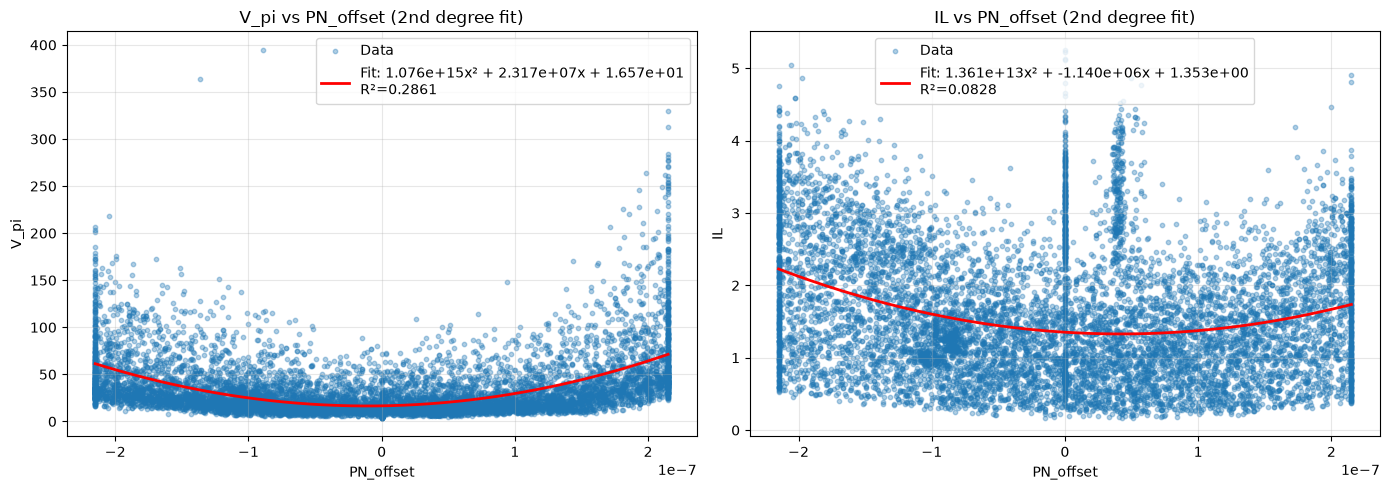

V_pi fit:   y = 1.075911e+15x² + 2.316792e+07x + 1.656621e+01, R² = 0.286119
IL fit:     y = 1.360575e+13x² + -1.139811e+06x + 1.352634e+00, R² = 0.082825


In [11]:

# Fit 2nd degree polynomials for V_pi and IL vs PN_offset
pn_offset = df_cleaned["PN_offset"].to_numpy()
vpi = df_cleaned["V_pi"].to_numpy()
il = df_cleaned["IL"].to_numpy()

mask = (
    np.isfinite(pn_offset) & np.isfinite(vpi) & np.isfinite(il)
)
pn_offset_fit = pn_offset[mask]
vpi_fit = vpi[mask]
il_fit = il[mask]

# Fit 2nd degree polynomials
coeffs_vpi = np.polyfit(pn_offset_fit, vpi_fit, 2)
coeffs_il = np.polyfit(pn_offset_fit, il_fit, 2)

poly_vpi = np.poly1d(coeffs_vpi)
poly_il = np.poly1d(coeffs_il)

# Predictions
vpi_pred = poly_vpi(pn_offset_fit)
il_pred = poly_il(pn_offset_fit)

# R^2 scores
r2_vpi = 1 - np.sum((vpi_fit - vpi_pred) ** 2) / np.sum((vpi_fit - vpi_fit.mean()) ** 2)
r2_il = 1 - np.sum((il_fit - il_pred) ** 2) / np.sum((il_fit - il_fit.mean()) ** 2)

# Smooth curves for plotting
x_line = np.linspace(pn_offset_fit.min(), pn_offset_fit.max(), 300)
vpi_line = poly_vpi(x_line)
il_line = poly_il(x_line)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].scatter(pn_offset_fit, vpi_fit, s=10, alpha=0.35, label="Data")
axs[0].plot(x_line, vpi_line, "r", lw=2, label=f"Fit: {coeffs_vpi[0]:.3e}x² + {coeffs_vpi[1]:.3e}x + {coeffs_vpi[2]:.3e}\nR²={r2_vpi:.4f}")
axs[0].set_title("V_pi vs PN_offset (2nd degree fit)")
axs[0].set_xlabel("PN_offset")
axs[0].set_ylabel("V_pi")
axs[0].grid(True, alpha=0.3)
axs[0].legend()

axs[1].scatter(pn_offset_fit, il_fit, s=10, alpha=0.35, label="Data")
axs[1].plot(x_line, il_line, "r", lw=2, label=f"Fit: {coeffs_il[0]:.3e}x² + {coeffs_il[1]:.3e}x + {coeffs_il[2]:.3e}\nR²={r2_il:.4f}")
axs[1].set_title("IL vs PN_offset (2nd degree fit)")
axs[1].set_xlabel("PN_offset")
axs[1].set_ylabel("IL")
axs[1].grid(True, alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.show()

print(f"V_pi fit:   y = {coeffs_vpi[0]:.6e}x² + {coeffs_vpi[1]:.6e}x + {coeffs_vpi[2]:.6e}, R² = {r2_vpi:.6f}")
print(f"IL fit:     y = {coeffs_il[0]:.6e}x² + {coeffs_il[1]:.6e}x + {coeffs_il[2]:.6e}, R² = {r2_il:.6f}")

## GPU Setup

In [12]:
print(f"JAX devices: {jax.devices()}")
print(f"Using backend: {jax.default_backend()}")
print(f"x_train_t device: {x_train_t.device}")

JAX devices: [CpuDevice(id=0)]
Using backend: cpu
x_train_t device: cpu:0


## Training Function
A self-contained training function that accepts all hyperparameters and returns the final train/val/test losses.

In [13]:
def train_model(
    model_ctor,  # Callable[[nnx.Rngs], nnx.Module] — builds the model to train
    batch_size=16,
    learning_rate=1e-3,
    weight_decay=0.05,
    betas=(0.9, 0.999),
    n_epoch=100,
    verbose=False,
    trial=None,  # Optuna trial for pruning
    early_stopping_patience=20,
    early_stopping_min_delta=1e-5,
    restore_best_weights=True,
    seed=random_state,
    x_train=None,
    y_train=None,
):
    """
    Build, train and evaluate a model with the given hyperparameters.

    `model_ctor(rngs) -> nnx.Module` builds the model; any architecture is
    supported as long as `model.__call__(x, *, train, rngs=None)` returns
    `(pred, new_stats)`, where `new_stats` is a plain nested dict/int-keyed
    structure whose shape matches `nnx.to_pure_dict(nnx.state(model,
    nnx.BatchStat))` — see MLP5/MultiGateMoE below for two conforming examples.

    x_train/y_train default to the module-level x_train_t/y_train_t but can be
    overridden (e.g. bootstrap-resampled or subsampled) for the comparison
    studies below; the held-out test set is always x_test_t/y_test_t.

    Each epoch's batches run as a single `jax.lax.scan` under one `jit` call
    instead of a Python loop dispatching one XLA call per batch, and per-split
    evaluation is a single whole-array forward pass instead of a batched loop
    — both avoid host/device round-trips that dominate runtime at this model
    size. Scanning over fixed-size batches means each epoch drops the last
    partial batch (equivalent to `drop_last=True`), which discards at most
    `batch_size - 1` samples per epoch.

    Returns
    -------
    dict with keys:
        'train_loss', 'test_loss',
        'train_history', 'test_history',
        'model_state'
    """
    x_train_data = x_train_t if x_train is None else x_train
    y_train_data = y_train_t if y_train is None else y_train

    # --- Build model ---
    init_key, epoch_key = jax.random.split(jax.random.PRNGKey(seed))
    model = model_ctor(nnx.Rngs(init_key))
    graphdef, params, batch_stats = nnx.split(model, nnx.Param, nnx.BatchStat)

    n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))

    tx = optax.adamw(
        learning_rate, weight_decay=weight_decay, b1=betas[0], b2=betas[1],
    )
    opt_state = tx.init(params)

    def apply_fn(params, batch_stats, x, dropout_key, train):
        m = nnx.merge(graphdef, params, batch_stats)
        dropout_rngs = nnx.Rngs(dropout=dropout_key) if train else None
        pred, new_stats = m(x, train=train, rngs=dropout_rngs)
        if not train:
            return pred, batch_stats
            
        def extract_val(v):
            return v.value if hasattr(v, 'value') else v
            
        def wrap_val(old_v, blended_arr):
            if hasattr(old_v, 'replace'):
                return old_v.replace(value=blended_arr)
            elif type(old_v).__name__ == 'VariableState':
                return type(old_v)(blended_arr)
            return blended_arr

        def blend_dict(old_d, new_d):
            res = {}
            for k in old_d:
                new_v = new_d.get(k)
                if new_v is None:
                    try:
                        new_v = new_d.get(int(k))
                    except (ValueError, TypeError):
                        pass
                if new_v is None:
                    try:
                        new_v = new_d.get(str(k))
                    except (ValueError, TypeError):
                        pass

                if hasattr(old_d[k], 'items'):
                    res[k] = blend_dict(dict(old_d[k]), new_d.get(k, new_v) or {})
                elif new_v is not None:
                    old_arr = extract_val(old_d[k])
                    new_arr = extract_val(new_v)
                    blended = BN_MOMENTUM * old_arr + (1 - BN_MOMENTUM) * new_arr
                    res[k] = wrap_val(old_d[k], blended)
                else:
                    res[k] = old_d[k]
            return res

        blended_pure = blend_dict(dict(batch_stats), new_stats)
        
        try:
            new_batch_stats = type(batch_stats)(blended_pure)
        except Exception:
            new_batch_stats = jax.tree_util.tree_map(lambda a: a, batch_stats)
            for k, v in blended_pure.items():
                if hasattr(new_batch_stats, k):
                    setattr(new_batch_stats, k, v)
        
        return pred, new_batch_stats

    def loss_fn(params, batch_stats, x_batch, y_batch, dropout_key):
        pred, new_batch_stats = apply_fn(params, batch_stats, x_batch, dropout_key, True)
        loss = jnp.mean((pred - y_batch) ** 2)
        return loss, new_batch_stats

    def train_step(params, batch_stats, opt_state, x_batch, y_batch, dropout_key):
        (loss, new_batch_stats), grads = jax.value_and_grad(loss_fn, has_aux=True)(
            params, batch_stats, x_batch, y_batch, dropout_key
        )
        updates, opt_state = tx.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, new_batch_stats, opt_state

    n_train = x_train_data.shape[0]
    n_batches = max(n_train // batch_size, 1)

    @jax.jit
    def run_epoch(params, batch_stats, opt_state, perm, drop_key):
        """One full epoch of training as a single scan (one XLA dispatch),
        instead of a Python loop issuing one dispatch per batch."""
        batch_idx = perm[: n_batches * batch_size].reshape(n_batches, batch_size)
        batch_keys = jax.random.split(drop_key, n_batches)

        def step(carry, xs):
            params, batch_stats, opt_state = carry
            idx, key = xs
            x_batch = x_train_data[idx]
            y_batch = y_train_data[idx]
            params, batch_stats, opt_state = train_step(
                params, batch_stats, opt_state, x_batch, y_batch, key
            )
            return (params, batch_stats, opt_state), None

        (params, batch_stats, opt_state), _ = jax.lax.scan(
            step, (params, batch_stats, opt_state), (batch_idx, batch_keys)
        )
        return params, batch_stats, opt_state

    @jax.jit
    def eval_loss(params, batch_stats, x, y):
        pred, _ = apply_fn(params, batch_stats, x, None, False)
        return jnp.mean((pred - y) ** 2)

    train_hist = np.zeros(n_epoch)
    test_hist  = np.zeros(n_epoch)

    # --- Early stopping bookkeeping ---
    best_test_loss = float('inf')
    best_epoch = -1
    epochs_without_improvement = 0
    best_state = None
    stopped_epoch = n_epoch - 1

    # --- Training loop ---
    epoch_iter = tqdm(
        range(n_epoch),
        desc="Training",
        dynamic_ncols=True,
        leave=False,
        colour="cyan",
        disable=not verbose,
    )

    for epoch in epoch_iter:
        epoch_key, perm_key, drop_key = jax.random.split(epoch_key, 3)
        perm = jax.random.permutation(perm_key, n_train)
        params, batch_stats, opt_state = run_epoch(params, batch_stats, opt_state, perm, drop_key)

        # --- Evaluation ---
        train_loss = float(eval_loss(params, batch_stats, x_train_data, y_train_data))
        test_loss = float(eval_loss(params, batch_stats, x_test_t, y_test_t))
        train_hist[epoch] = train_loss
        test_hist[epoch] = test_loss

        if verbose:
            epoch_iter.set_postfix({
                "train": f"{train_loss:.4e}",
                "test": f"{test_loss:.4e}",
                "best": f"{best_test_loss:.4e}" if np.isfinite(best_test_loss) else "inf",
            })

        # Optuna pruning
        if trial is not None:
            trial.report(test_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        # Early stopping (based on test loss)
        if test_loss < (best_test_loss - early_stopping_min_delta):
            best_test_loss = test_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            if restore_best_weights:
                best_state = (params, batch_stats)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stopping_patience:
            stopped_epoch = epoch
            if verbose:
                print(
                    f"Early stopping at epoch {epoch} (best epoch: {best_epoch}, best test: {best_test_loss:.6f})"
                )
            break

    # Keep only executed part of histories
    executed_epochs = stopped_epoch + 1
    train_hist = train_hist[:executed_epochs]
    test_hist = test_hist[:executed_epochs]

    # Restore best weights if requested and available
    if restore_best_weights and best_state is not None:
        params, batch_stats = best_state

    # Re-evaluate final model (restored best if enabled)
    final_train_loss = float(eval_loss(params, batch_stats, x_train_data, y_train_data))
    final_test_loss = float(eval_loss(params, batch_stats, x_test_t, y_test_t))

    return {
        'train_loss': final_train_loss,
        'test_loss':  final_test_loss,
        'best_test_loss': best_test_loss,
        'best_epoch': best_epoch,
        'stopped_epoch': stopped_epoch,
        'train_history': train_hist,
        'test_history':  test_hist,
        'model_state': (graphdef, params, batch_stats),
        'n_params': n_params,
    }

## Training Model

In [14]:
base_train = train_model(
    model_ctor=lambda rngs: MLP5(input_dim=8, output_dim=3, dropout=0.2,
                                  hidden_dims=(200, 300, 350, 300, 200), rngs=rngs),
    verbose=True,
)

print(f"Base train loss: {base_train['train_loss']:.6f}")
print(f"Base test loss: {base_train['test_loss']:.6f}")

Training:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\M Ali\AppData\Local\Temp\ipykernel_15088\3554089872.py:68: DeprecationWarning: '.value' access is now deprecated. For Variable[Array] instances use:

  variable[...]

For other Variable types use:

  variable.get_value()

  return v.value if hasattr(v, 'value') else v
                                                                                                              3098e-02]

Early stopping at epoch 52 (best epoch: 32, best test: 0.023098)
Base train loss: 0.029471
Base test loss: 0.023098


### Hyperparameter Search for MMoE

`train_model` above already accepts an Optuna `trial` and reports the running test loss every epoch (see the "Optuna pruning" block near the end of its training loop) — that machinery has been sitting unused until now.

Rather than hand-picking MMoE's architecture and optimizer settings, this section searches for them first, and the result becomes the canonical `mmoe_train` used for the rest of the notebook (loss curves, the comparison table below, and as MMoE's default configuration in the Architecture Comparison section further down):

| Hyperparameter | Search space | What it controls |
|---|---|---|
| `n_experts` | 6 – 25 | how many experts share the load |
| `width_scale` | 0.15 – 1.5 (log) | expert width, applied to `_MMOE_SHAPE_TEMPLATE` (defined above, alongside the model classes), so experts keep that expand-then-shrink shape at a different size |
| `gating_hidden` | 8 – 64 | capacity of each per-task gating network |
| `dropout` | 0.0 – 0.4 | regularization inside each expert |
| `learning_rate` | 1e-4 – 1e-2 (log) | Adam step size |
| `weight_decay` | 1e-5 – 3e-1 (log) | AdamW weight decay |
| `batch_size` | {16, 32, 64, 128} | training batch size |

Each trial trains for up to 60 epochs with early stopping (patience 15) *and* Optuna's `MedianPruner`, which cuts a trial short once its test loss falls behind the median of comparable trials at the same epoch — so most weak configurations get cut off well before 60 epochs, keeping the search affordable. `n_trials=40` below is a starting point; raise it, or pass `timeout=<seconds>` to `study.optimize`, if you have more time to spend. On CPU expect roughly a few seconds to ~1 minute per (possibly pruned) trial, depending on model size and how early it's pruned.

In [ ]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)  # keep trial-by-trial spam out of the notebook


def mmoe_objective(trial):
    n_experts = trial.suggest_int("n_experts", 6, 30)
    width_scale = trial.suggest_float("width_scale", 0.15, 1.5, log=True)
    gating_hidden = trial.suggest_int("gating_hidden", 8, 64)
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 3e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])

    # Keep the same expand-to-peak-then-shrink expert shape used throughout
    # this notebook (_MMOE_SHAPE_TEMPLATE, defined above), just resized.
    expert_hidden_dims = tuple(max(4, round(d * width_scale)) for d in _MMOE_SHAPE_TEMPLATE)

    model_ctor = lambda rngs: MultiGateMoE(
        input_dim=8, output_dim=3, n_experts=n_experts,
        expert_hidden_dims=expert_hidden_dims, gating_hidden=gating_hidden,
        dropout=dropout, rngs=rngs,
    )

    result = train_model(
        model_ctor=model_ctor,
        batch_size=batch_size,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        n_epoch=60,
        early_stopping_patience=15,
        trial=trial,  # enables the MedianPruner reporting inside train_model
        seed=123,
    )

    trial.set_user_attr("n_params", result["n_params"])
    trial.set_user_attr("expert_hidden_dims", expert_hidden_dims)
    return result["test_loss"]

In [16]:
sampler = optuna.samplers.TPESampler(seed=123)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=10)
study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

study.optimize(mmoe_objective, n_trials=40, show_progress_bar=True)

n_pruned = sum(t.state == optuna.trial.TrialState.PRUNED for t in study.trials)
n_complete = sum(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials)
print(f"{n_complete} completed, {n_pruned} pruned, out of {len(study.trials)} trials")
print(f"Best test MSE: {study.best_value:.6f}  (n_params={study.best_trial.user_attrs['n_params']})")
print("Best hyperparameters:")
for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")

  0%|          | 0/40 [00:00<?, ?it/s]C:\Users\M Ali\AppData\Local\Temp\ipykernel_15088\3554089872.py:68: DeprecationWarning: '.value' access is now deprecated. For Variable[Array] instances use:

  variable[...]

For other Variable types use:

  variable.get_value()

  return v.value if hasattr(v, 'value') else v
Best trial: 32. Best value: 0.00670592: 100%|██████████| 40/40 [1:02:46<00:00, 94.16s/it] 

15 completed, 25 pruned, out of 40 trials
Best test MSE: 0.006706  (n_params=617139)
Best hyperparameters:
  n_experts: 9
  width_scale: 0.4458156684740902
  gating_hidden: 20
  dropout: 0.3103287903902185
  learning_rate: 0.007584508968993816
  weight_decay: 2.064610858990432e-05
  batch_size: 16


C:\Users\M Ali\AppData\Local\Temp\ipykernel_15088\3208242982.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  opt_mpl.plot_optimization_history(study)


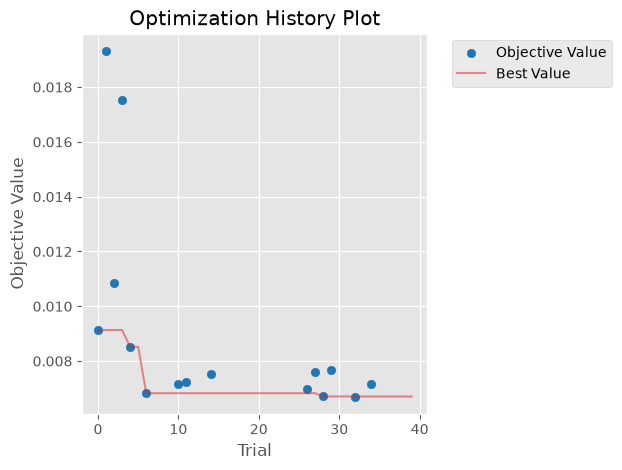

C:\Users\M Ali\AppData\Local\Temp\ipykernel_15088\3208242982.py:7: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  opt_mpl.plot_param_importances(study)


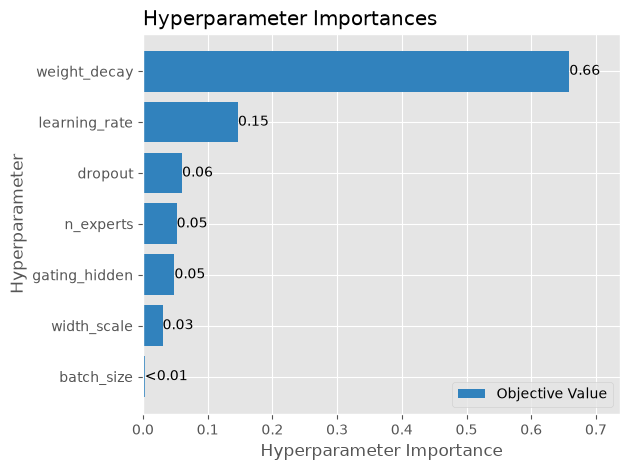

In [17]:
import optuna.visualization.matplotlib as opt_mpl

opt_mpl.plot_optimization_history(study)
plt.tight_layout()
plt.show()

opt_mpl.plot_param_importances(study)
plt.tight_layout()
plt.show()

In [18]:
# Train the canonical MMoE at the best hyperparameters found above, with a
# larger epoch budget than the search used (60 epochs/patience 15 there was
# tuned for search speed, not final quality).
best = study.best_trial.params
best_dims = tuple(max(4, round(d * best["width_scale"])) for d in _MMOE_SHAPE_TEMPLATE)

mmoe_train = train_model(
    model_ctor=lambda rngs: MultiGateMoE(
        input_dim=8, output_dim=3, n_experts=best["n_experts"],
        expert_hidden_dims=best_dims, gating_hidden=best["gating_hidden"],
        dropout=best["dropout"], rngs=rngs,
    ),
    batch_size=best["batch_size"],
    learning_rate=best["learning_rate"],
    weight_decay=best["weight_decay"],
    n_epoch=150,
    early_stopping_patience=25,
    verbose=True,
)

print(f"MMoE train loss: {mmoe_train['train_loss']:.6f}")
print(f"MMoE test loss:  {mmoe_train['test_loss']:.6f}")

Training:   0%|          | 0/150 [00:00<?, ?it/s]C:\Users\M Ali\AppData\Local\Temp\ipykernel_15088\3554089872.py:68: DeprecationWarning: '.value' access is now deprecated. For Variable[Array] instances use:

  variable[...]

For other Variable types use:

  variable.get_value()

  return v.value if hasattr(v, 'value') else v


Early stopping at epoch 79 (best epoch: 54, best test: 0.006706)
MMoE train loss: 0.013900
MMoE test loss:  0.006706


In [19]:
import json
import pickle

best_hyperparams = dict(best)
best_hyperparams["expert_hidden_dims"] = list(best_dims)
best_hyperparams["n_params"] = mmoe_train["n_params"]
best_hyperparams["test_loss"] = mmoe_train["test_loss"]
best_hyperparams["train_loss"] = mmoe_train["train_loss"]

with open("best_hyperparams.json", "w") as f:
    json.dump(best_hyperparams, f, indent=2)

with open("best_model.pkl", "wb") as f:
    pickle.dump(mmoe_train["model_state"], f)

print("Saved best_hyperparams.json and best_model.pkl")

# To reload later:
#   with open("best_model.pkl", "rb") as f:
#       graphdef, params, batch_stats = pickle.load(f)
#   model = nnx.merge(graphdef, params, batch_stats)

Saved best_hyperparams.json and best_model.pkl


In [20]:
print(f"{'Model':<10}{'Params':>10}{'Train MSE':>14}{'Test MSE':>14}")
for name, res in [("MLP5", base_train), ("MMoE", mmoe_train)]:
    print(f"{name:<10}{res['n_params']:>10,}{res['train_loss']:>14.6f}{res['test_loss']:>14.6f}")

Model         Params     Train MSE      Test MSE
MLP5         336,253      0.029471      0.023098
MMoE         617,139      0.013900      0.006706


## Results

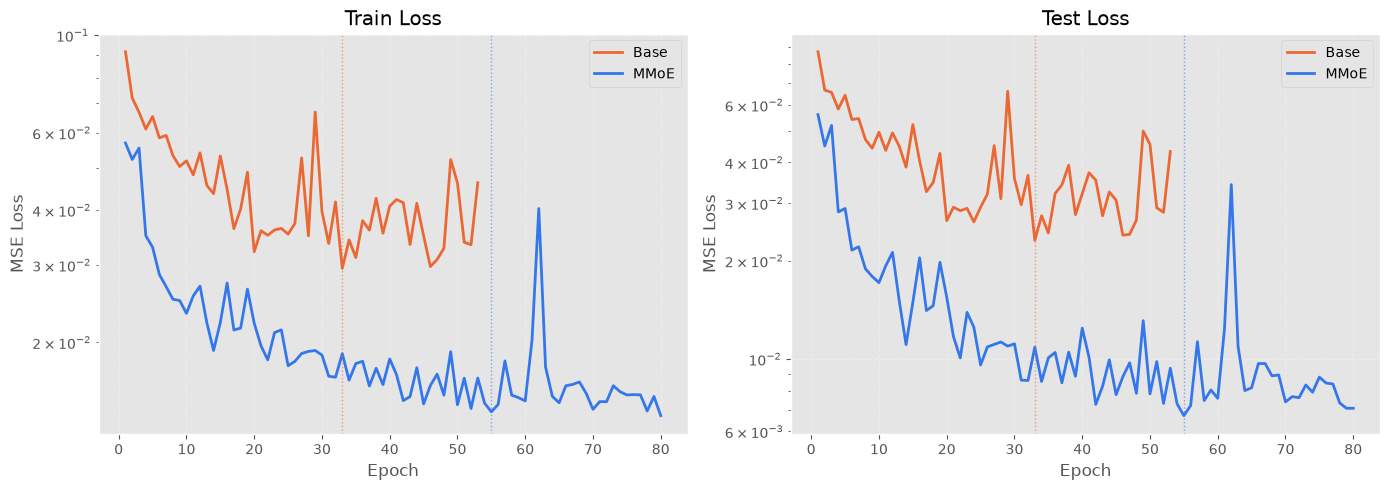

In [21]:
color_base = "#eb6834"
color_mmoe = "#3477eb"

epochs_base = np.arange(1, len(base_train["train_history"]) + 1)
epochs_mmoe = np.arange(1, len(mmoe_train["train_history"]) + 1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(epochs_base, base_train["train_history"], color=color_base, lw=2, label="Base")
axs[0].plot(epochs_mmoe, mmoe_train["train_history"], color=color_mmoe, lw=2, label="MMoE")
axs[0].axvline(base_train["best_epoch"] + 1, color=color_base, lw=1, linestyle=":", alpha=0.6)
axs[0].axvline(mmoe_train["best_epoch"] + 1, color=color_mmoe, lw=1, linestyle=":", alpha=0.6)
axs[0].set_yscale("log")
axs[0].set_title("Train Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("MSE Loss")
axs[0].grid(True, linestyle="--", alpha=0.3)
axs[0].legend()

axs[1].plot(epochs_base, base_train["test_history"], color=color_base, lw=2, label="Base")
axs[1].plot(epochs_mmoe, mmoe_train["test_history"], color=color_mmoe, lw=2, label="MMoE")
axs[1].axvline(base_train["best_epoch"] + 1, color=color_base, lw=1, linestyle=":", alpha=0.6)
axs[1].axvline(mmoe_train["best_epoch"] + 1, color=color_mmoe, lw=1, linestyle=":", alpha=0.6)
axs[1].set_yscale("log")
axs[1].set_title("Test Loss")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("MSE Loss")
axs[1].grid(True, linestyle="--", alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.show()

## Architecture Comparison

A reusable scaffold for comparing Base MLP against a second architecture along three axes:

1. **Parameter efficiency** — test loss vs. parameter count.
2. **Variance** — spread of test loss across bootstrap-resampled training sets.
3. **Data efficiency** — test loss vs. training set size.

The second entry is `"mmoe"` — the `MultiGateMoE` above, using the hyperparameters found by the Optuna search (`best`/`best_dims`): `best["n_experts"]` always-active experts, each shaped like Base's own expand-to-peak-then-shrink hidden_dims profile (resized to `best_dims`), shared across all three outputs but combined by a separate softmax gate per output. Its *width* is nonetheless re-matched to Base at every comparison point below (the bootstrap-variance and data-efficiency studies use it as-is, sized independently — an earlier dense-MoE attempt on this dataset used 60 experts x [64,128,64] at ~3x Base's params, and any performance difference it showed was confounded by that capacity gap, which is why the parameter-efficiency sweep instead re-matches MMoE's expert *width* to Base's *actual measured* `n_params` at each scale point via `mmoe_scale_matching` — holding `best`'s n_experts/gating_hidden/dropout fixed and only rescaling width — so that sweep's x-axis genuinely compares architectures at equal capacity.

When a third architecture is ready to compare, add its results under a new key alongside `"base"`/`"mmoe"` in each cell's lists/dicts and the plots/summary below will pick it up unchanged.

*Sweep runs use a shorter epoch budget (60 epochs, patience 15) than the canonical runs above (Base: 100/20 default; tuned MMoE: 150/25) to keep total runtime bounded — comparisons are only meaningful within a sweep (same epoch budget), never across different epoch budgets.*

In [22]:
n_full = x_train_t.shape[0]

ARCHS = {
    "base": {
        "ctor_factory": lambda dims: (lambda rngs: MLP5(
            input_dim=8, output_dim=3, dropout=0.2, hidden_dims=dims, rngs=rngs)),
        "default_dims": (200, 300, 350, 300, 200),
    },
    "mmoe": {
        # Uses the tuned hyperparameters found by the Optuna search above
        # (n_experts, gating_hidden, dropout, and width via best_dims), so
        # this "default" is the actual best-found MMoE, not a guess.
        "ctor_factory": lambda dims: (lambda rngs: MultiGateMoE(
            input_dim=8, output_dim=3, n_experts=best["n_experts"], expert_hidden_dims=dims,
            gating_hidden=best["gating_hidden"], dropout=best["dropout"], rngs=rngs)),
        "default_dims": best_dims,
    },
}


def run_config(name="base", *, hidden_dims=None, frac=1.0, bootstrap=False,
                seed=123, n_epoch=60, patience=15):
    """Train architecture `name` ("base" or "mmoe") on a possibly resampled
    training set. `hidden_dims` is that architecture's scaling knob — Base's
    5-tuple of trunk widths, or MMoE's 5-tuple of expert widths (same
    expand-to-peak-then-shrink shape as Base's, just at expert scale).

    bootstrap=True resamples n_full points WITH replacement (variance study);
    frac<1 draws a smaller subset WITHOUT replacement (data-efficiency study).
    """
    rng = np.random.default_rng(seed)
    x_tr, y_tr = x_train_t, y_train_t
    if bootstrap:
        idx = rng.integers(0, n_full, size=n_full)
        x_tr, y_tr = x_tr[idx], y_tr[idx]
    elif frac < 1.0:
        n_sub = max(int(round(n_full * frac)), 32)
        idx = rng.choice(n_full, size=n_sub, replace=False)
        x_tr, y_tr = x_tr[idx], y_tr[idx]

    dims = hidden_dims if hidden_dims is not None else ARCHS[name]["default_dims"]
    model_ctor = ARCHS[name]["ctor_factory"](dims)

    return train_model(
        model_ctor=model_ctor,
        n_epoch=n_epoch,
        early_stopping_patience=patience,
        seed=seed,
        x_train=x_tr,
        y_train=y_tr,
    )


def _extract(results, key):
    return np.array([row[key] for row in results])


def _count_mmoe_params(hidden_dims):
    m = ARCHS["mmoe"]["ctor_factory"](hidden_dims)(nnx.Rngs(0))
    _, params, _ = nnx.split(m, nnx.Param, nnx.BatchStat)
    return sum(p.size for p in jax.tree_util.tree_leaves(params))


def mmoe_scale_matching(target_params, lo=0.01, hi=3.0, iters=40):
    """Bisect the scalar `s` applied to _MMOE_SHAPE_TEMPLATE (i.e. expert
    hidden dims = round(d * s) for d in the template, preserving Base's
    expand-to-peak-then-shrink shape at expert scale) whose resulting MMoE
    n_params is closest to `target_params`; n_experts/gating_hidden held at
    ARCHS['mmoe'] defaults. Keeps the parameter-efficiency sweep's MMoE points
    matched to Base's n_params at that same sweep point, not just at
    scale=1.0."""
    def dims_for(s):
        return tuple(max(4, round(d * s)) for d in _MMOE_SHAPE_TEMPLATE)

    for _ in range(iters):
        mid = (lo + hi) / 2
        if _count_mmoe_params(dims_for(mid)) < target_params:
            lo = mid
        else:
            hi = mid
    s = (lo + hi) / 2
    dims = dims_for(s)
    return dims, _count_mmoe_params(dims)

### 1. Parameter Efficiency

Scale every hidden layer of `MLP5` by a common factor and compare test loss vs. parameter count. At each Base scale point, MMoE's expert-shape scale is re-matched to Base's *actual measured* `n_params` at that point (each expert keeps Base's expand-to-peak-then-shrink profile, just resized) via `mmoe_scale_matching`, so the x-axis compares architectures at equal capacity throughout, not just at scale=1.0.

In [23]:
base_dims = np.array([200, 300, 350, 300, 200])
scale_factors = [1.0, 0.7, 0.5, 0.35, 0.25, 0.15, 0.08]

param_results = {"base": [], "mmoe": []}
for scale in tqdm(scale_factors, desc="Parameter sweep"):
    dims = tuple(int(max(4, round(d * scale))) for d in base_dims)
    r_base = run_config("base", hidden_dims=dims, seed=123)
    param_results["base"].append({
        "scale": scale, "hidden_dims": dims,
        "n_params": r_base["n_params"], "test_loss": r_base["test_loss"], "train_loss": r_base["train_loss"],
    })

    mmoe_dims, _ = mmoe_scale_matching(r_base["n_params"])
    r_mmoe = run_config("mmoe", hidden_dims=mmoe_dims, seed=123)
    param_results["mmoe"].append({
        "scale": scale, "hidden_dims": mmoe_dims,
        "n_params": r_mmoe["n_params"], "test_loss": r_mmoe["test_loss"], "train_loss": r_mmoe["train_loss"],
    })

for name in ["base", "mmoe"]:
    for row in param_results[name]:
        print(f"{name:4s} scale={row['scale']:.2f} n_params={row['n_params']:>7d} test_loss={row['test_loss']:.5f}")

Parameter sweep:   0%|          | 0/7 [00:00<?, ?it/s]C:\Users\M Ali\AppData\Local\Temp\ipykernel_15088\3554089872.py:68: DeprecationWarning: '.value' access is now deprecated. For Variable[Array] instances use:

  variable[...]

For other Variable types use:

  variable.get_value()

  return v.value if hasattr(v, 'value') else v
Parameter sweep: 100%|██████████| 7/7 [12:12<00:00, 104.59s/it]

base scale=1.00 n_params= 336253 test_loss=0.02310
base scale=0.70 n_params= 166078 test_loss=0.02189
base scale=0.50 n_params=  85628 test_loss=0.02366
base scale=0.35 n_params=  42509 test_loss=0.02390
base scale=0.25 n_params=  22267 test_loss=0.02633
base scale=0.15 n_params=   8319 test_loss=0.03992
base scale=0.08 n_params=   2615 test_loss=0.05538
mmoe scale=1.00 n_params= 335205 test_loss=0.01336
mmoe scale=0.70 n_params= 165600 test_loss=0.01247
mmoe scale=0.50 n_params=  86166 test_loss=0.01343
mmoe scale=0.35 n_params=  42948 test_loss=0.01486
mmoe scale=0.25 n_params=  21555 test_loss=0.01541
mmoe scale=0.15 n_params=   8379 test_loss=0.01652
mmoe scale=0.08 n_params=   2646 test_loss=0.02110


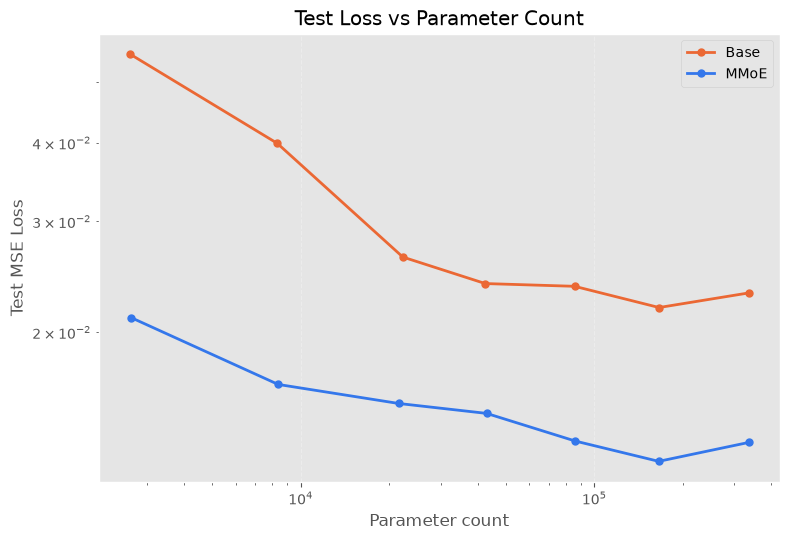

base: full-size test_loss=0.02310 (336253 params); smallest model within 19% of that uses 22267 params (scale=0.25, test_loss=0.02633)
mmoe: full-size test_loss=0.01336 (335205 params); smallest model within 19% of that uses 21555 params (scale=0.25, test_loss=0.01541)


In [24]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for name, color, label in [("base", color_base, "Base"), ("mmoe", color_mmoe, "MMoE")]:
    n_params_arr = _extract(param_results[name], "n_params")
    test_loss_arr = _extract(param_results[name], "test_loss")
    order = np.argsort(n_params_arr)
    ax.plot(n_params_arr[order], test_loss_arr[order], color=color, lw=2, marker="o", markersize=5, label=label)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Parameter count")
ax.set_ylabel("Test MSE Loss")
ax.set_title("Test Loss vs Parameter Count")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Smallest model within 20% of that model's own full-size test loss
tolerance = 1.2
for name in ["base", "mmoe"]:
    full_loss = param_results[name][0]["test_loss"]  # scale=1.0 is first entry
    within = [row for row in param_results[name] if row["test_loss"] <= tolerance * full_loss]
    smallest = min(within, key=lambda row: row["n_params"])
    print(
        f"{name}: full-size test_loss={full_loss:.5f} ({param_results[name][0]['n_params']} params); "
        f"smallest model within {int((tolerance - 1) * 100)}% of that uses {smallest['n_params']} params "
        f"(scale={smallest['scale']}, test_loss={smallest['test_loss']:.5f})"
    )

### 2. Estimate Variance (Bootstrap)

Retrain each model 15 times on bootstrap resamples of the training set (same size, sampled with replacement) with a different seed each time. This measures whether the two architectures give more or less consistent predictions across different training realizations, not just the average test loss.

In [25]:
n_bootstrap = 15

variance_results = {"base": [], "mmoe": []}
for i in tqdm(range(n_bootstrap), desc="Bootstrap"):
    seed = 1000 + i
    for name in ["base", "mmoe"]:
        r = run_config(name, seed=seed, bootstrap=True)
        variance_results[name].append({
            "seed": seed, "test_loss": r["test_loss"], "train_loss": r["train_loss"],
            "model_state": r["model_state"],
        })

for name in ["base", "mmoe"]:
    losses = _extract(variance_results[name], "test_loss")
    print(f"{name}: test_loss mean={losses.mean():.5f} std={losses.std():.5f} (n={len(losses)})")

Bootstrap:   0%|          | 0/15 [00:00<?, ?it/s]C:\Users\M Ali\AppData\Local\Temp\ipykernel_15088\3554089872.py:68: DeprecationWarning: '.value' access is now deprecated. For Variable[Array] instances use:

  variable[...]

For other Variable types use:

  variable.get_value()

  return v.value if hasattr(v, 'value') else v
Bootstrap: 100%|██████████| 15/15 [58:51<00:00, 235.46s/it]

base: test_loss mean=0.02174 std=0.00211 (n=15)
mmoe: test_loss mean=0.01358 std=0.00094 (n=15)


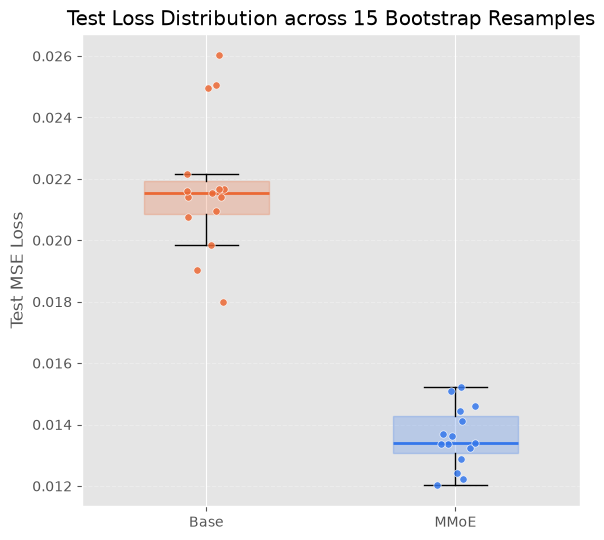

In [26]:
fig, ax = plt.subplots(figsize=(6, 5.5))

data_box = [
    [row["test_loss"] for row in variance_results["base"]],
    [row["test_loss"] for row in variance_results["mmoe"]],
]
bp = ax.boxplot(data_box, positions=[0, 1], widths=0.5, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], [color_base, color_mmoe]):
    patch.set_facecolor(color)
    patch.set_alpha(0.25)
    patch.set_edgecolor(color)
for median, color in zip(bp["medians"], [color_base, color_mmoe]):
    median.set_color(color)
    median.set_linewidth(2)

rng_jitter = np.random.default_rng(0)
for pos, name, color in [(0, "base", color_base), (1, "mmoe", color_mmoe)]:
    ys = [row["test_loss"] for row in variance_results[name]]
    xs = pos + rng_jitter.uniform(-0.08, 0.08, size=len(ys))
    ax.scatter(xs, ys, color=color, s=28, alpha=0.85, edgecolors="white", linewidth=0.5, zorder=3)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Base", "MMoE"])
ax.set_ylabel("Test MSE Loss")
ax.set_title(f"Test Loss Distribution across {n_bootstrap} Bootstrap Resamples")
ax.grid(True, linestyle="--", alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

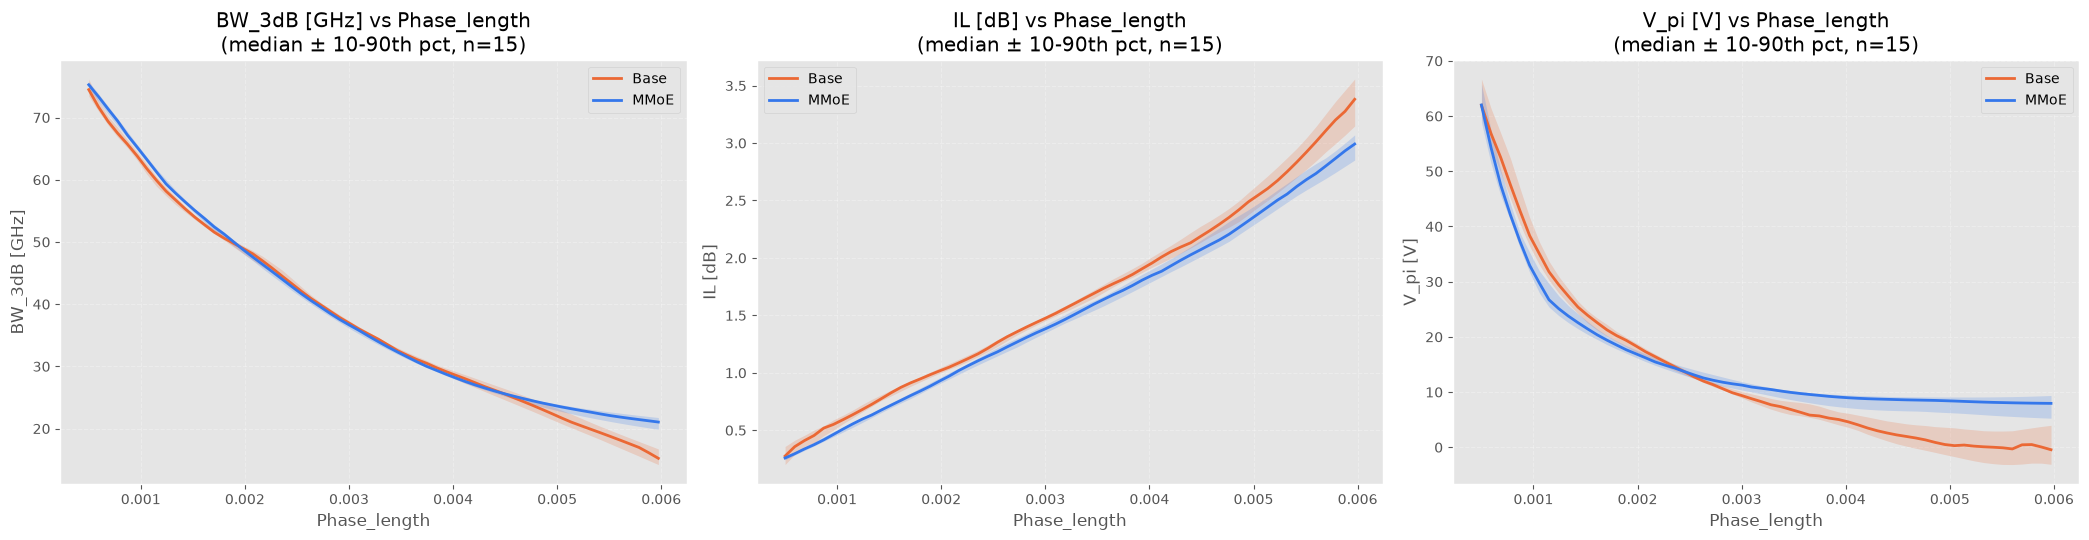

BW_3dB [GHz] base: mean 10-90th band width = 1.427 (2.4% of Base's full curve range)
BW_3dB [GHz] mmoe: mean 10-90th band width = 0.9584 (1.6% of Base's full curve range)
IL [dB]      base: mean 10-90th band width = 0.1195 (3.8% of Base's full curve range)
IL [dB]      mmoe: mean 10-90th band width = 0.09662 (3.1% of Base's full curve range)
V_pi [V]     base: mean 10-90th band width = 3.475 (5.6% of Base's full curve range)
V_pi [V]     mmoe: mean 10-90th band width = 2.577 (4.1% of Base's full curve range)


In [27]:
# Predicted BW_3dB / IL / V_pi vs Phase_length, holding the other 7 features
# at their median training value — shows how consistently each model's
# predicted physical trend behaves across the bootstrap ensemble.
PHASE_LENGTH_COL = 7
grid_n = 60
phase_grid = np.linspace(
    x_train_raw[:, PHASE_LENGTH_COL].min(), x_train_raw[:, PHASE_LENGTH_COL].max(), grid_n
)
median_features = np.median(x_train_raw, axis=0)
grid_raw = np.tile(median_features, (grid_n, 1))
grid_raw[:, PHASE_LENGTH_COL] = phase_grid
grid_scaled = jnp.asarray(scaler_x.transform(grid_raw), dtype=jnp.float32)


def predict_grid(model_state):
    graphdef, params, batch_stats = model_state
    m = nnx.merge(graphdef, params, batch_stats)
    pred, _ = m(grid_scaled, train=False)
    pred = np.asarray(pred)
    bw = scaler_y1.inverse_transform(pred[:, 0:1]).ravel()
    il = scaler_y2.inverse_transform(pred[:, 1:2]).ravel()
    vpi = scaler_y3.inverse_transform(pred[:, 2:3]).ravel()
    return bw, il, vpi


curve_results = {"base": {"bw": [], "il": [], "vpi": []}, "mmoe": {"bw": [], "il": [], "vpi": []}}
for name in ["base", "mmoe"]:
    for row in variance_results[name]:
        bw, il, vpi = predict_grid(row["model_state"])
        curve_results[name]["bw"].append(bw)
        curve_results[name]["il"].append(il)
        curve_results[name]["vpi"].append(vpi)

fig, axs = plt.subplots(1, 3, figsize=(21, 5.5))
titles = [("bw", "BW_3dB [GHz]"), ("il", "IL [dB]"), ("vpi", "V_pi [V]")]
for ax, (key, ylabel) in zip(axs, titles):
    for name, color, label in [("base", color_base, "Base"), ("mmoe", color_mmoe, "MMoE")]:
        curves = np.array(curve_results[name][key])  # (n_bootstrap, grid_n)
        lo, med, hi = np.percentile(curves, [10, 50, 90], axis=0)
        ax.fill_between(phase_grid, lo, hi, color=color, alpha=0.2, linewidth=0)
        ax.plot(phase_grid, med, color=color, lw=2, label=label)
    ax.set_xlabel("Phase_length")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs Phase_length\n(median ± 10-90th pct, n={n_bootstrap})")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

# Numeric spread comparison: mean 10-90th percentile band width, relative to
# the BASE model's own median-curve range for that output (a single stable,
# non-zero denominator shared by both models) rather than the pointwise
# median value — a pointwise denominator blows up wherever a curve crosses
# zero, which would misrepresent a normal-sized absolute band as a huge
# relative one.
for key, label in titles:
    base_med = np.percentile(np.array(curve_results["base"][key]), 50, axis=0)
    scale = base_med.max() - base_med.min()
    for name in ["base", "mmoe"]:
        curves = np.array(curve_results[name][key])
        lo, hi = np.percentile(curves, [10, 90], axis=0)
        band_width = np.mean(hi - lo)
        print(f"{label:12s} {name:4s}: mean 10-90th band width = {band_width:.4g} ({band_width / scale * 100:.1f}% of Base's full curve range)")

### 3. Data Efficiency

Subsample the training set (without replacement) to a range of sizes and evaluate on the same held-out test set, to see whether either architecture needs fewer labeled examples to reach comparable performance.

In [28]:
data_fractions = [1.0, 0.5, 0.25, 0.125, 0.0625, 0.03, 0.015]

data_results = {"base": [], "mmoe": []}
for frac in tqdm(data_fractions, desc="Data efficiency"):
    for name in ["base", "mmoe"]:
        r = run_config(name, frac=frac, seed=123)
        data_results[name].append({
            "frac": frac, "n_train": int(round(frac * n_full)),
            "test_loss": r["test_loss"], "train_loss": r["train_loss"],
        })

for name in ["base", "mmoe"]:
    for row in data_results[name]:
        print(f"{name:4s} n_train={row['n_train']:>5d} ({row['frac'] * 100:5.1f}%) test_loss={row['test_loss']:.5f}")

Data efficiency:   0%|          | 0/7 [00:00<?, ?it/s]C:\Users\M Ali\AppData\Local\Temp\ipykernel_15088\3554089872.py:68: DeprecationWarning: '.value' access is now deprecated. For Variable[Array] instances use:

  variable[...]

For other Variable types use:

  variable.get_value()

  return v.value if hasattr(v, 'value') else v
Data efficiency: 100%|██████████| 7/7 [09:16<00:00, 79.50s/it] 

base n_train= 8652 (100.0%) test_loss=0.02310
base n_train= 4326 ( 50.0%) test_loss=0.04050
base n_train= 2163 ( 25.0%) test_loss=0.04628
base n_train= 1082 ( 12.5%) test_loss=0.05159
base n_train=  541 (  6.2%) test_loss=0.07214
base n_train=  260 (  3.0%) test_loss=0.10676
base n_train=  130 (  1.5%) test_loss=0.14238
mmoe n_train= 8652 (100.0%) test_loss=0.01369
mmoe n_train= 4326 ( 50.0%) test_loss=0.01844
mmoe n_train= 2163 ( 25.0%) test_loss=0.02796
mmoe n_train= 1082 ( 12.5%) test_loss=0.04144
mmoe n_train=  541 (  6.2%) test_loss=0.06956
mmoe n_train=  260 (  3.0%) test_loss=0.10153
mmoe n_train=  130 (  1.5%) test_loss=0.16101


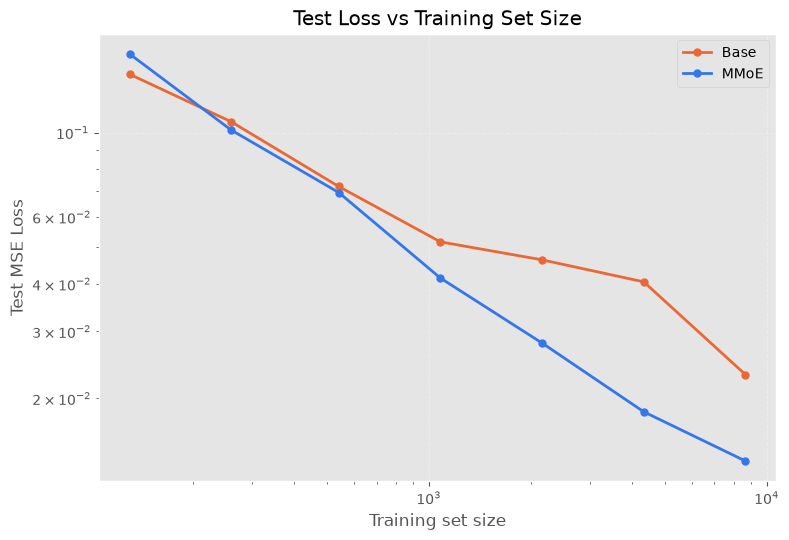

base: full-data test_loss=0.02310 (n=8652); smallest training set within 19% of that uses n=8652 (100.0%, test_loss=0.02310)
mmoe: full-data test_loss=0.01369 (n=8652); smallest training set within 19% of that uses n=8652 (100.0%, test_loss=0.01369)


In [29]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for name, color, label in [("base", color_base, "Base"), ("mmoe", color_mmoe, "MMoE")]:
    n_train_arr = _extract(data_results[name], "n_train")
    test_loss_arr = _extract(data_results[name], "test_loss")
    order = np.argsort(n_train_arr)
    ax.plot(n_train_arr[order], test_loss_arr[order], color=color, lw=2, marker="o", markersize=5, label=label)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Training set size")
ax.set_ylabel("Test MSE Loss")
ax.set_title("Test Loss vs Training Set Size")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Smallest training set within 20% of that model's own full-data test loss
tolerance = 1.2
for name in ["base", "mmoe"]:
    full_loss = data_results[name][0]["test_loss"]  # frac=1.0 is first entry
    within = [row for row in data_results[name] if row["test_loss"] <= tolerance * full_loss]
    smallest = min(within, key=lambda row: row["n_train"])
    print(
        f"{name}: full-data test_loss={full_loss:.5f} (n={data_results[name][0]['n_train']}); "
        f"smallest training set within {int((tolerance - 1) * 100)}% of that uses n={smallest['n_train']} "
        f"({smallest['frac'] * 100:.1f}%, test_loss={smallest['test_loss']:.5f})"
    )

### Summary

In [30]:
print("1) Parameter efficiency:")
for name in ["base", "mmoe"]:
    full_loss = param_results[name][0]["test_loss"]
    full_params = param_results[name][0]["n_params"]
    within = [row for row in param_results[name] if row["test_loss"] <= 1.2 * full_loss]
    smallest = min(within, key=lambda row: row["n_params"])
    reduction = 1 - smallest["n_params"] / full_params
    print(f"  {name}: {full_params} -> {smallest['n_params']} params ({reduction * 100:.0f}% fewer) within 20% of full-size test loss")

print()
print(f"2) Estimate variance (bootstrap, n={n_bootstrap}):")
for name in ["base", "mmoe"]:
    losses = _extract(variance_results[name], "test_loss")
    print(f"  {name}: test_loss = {losses.mean():.5f} +/- {losses.std():.5f} (std/mean = {losses.std() / losses.mean() * 100:.1f}%)")

print()
print("3) Data efficiency:")
for name in ["base", "mmoe"]:
    full_loss = data_results[name][0]["test_loss"]
    full_n = data_results[name][0]["n_train"]
    within = [row for row in data_results[name] if row["test_loss"] <= 1.2 * full_loss]
    smallest = min(within, key=lambda row: row["n_train"])
    reduction = 1 - smallest["n_train"] / full_n
    print(f"  {name}: {full_n} -> {smallest['n_train']} samples ({reduction * 100:.0f}% fewer) within 20% of full-data test loss")

1) Parameter efficiency:
  base: 336253 -> 22267 params (93% fewer) within 20% of full-size test loss
  mmoe: 335205 -> 21555 params (94% fewer) within 20% of full-size test loss

2) Estimate variance (bootstrap, n=15):
  base: test_loss = 0.02174 +/- 0.00211 (std/mean = 9.7%)
  mmoe: test_loss = 0.01358 +/- 0.00094 (std/mean = 6.9%)

3) Data efficiency:
  base: 8652 -> 8652 samples (0% fewer) within 20% of full-data test loss
  mmoe: 8652 -> 8652 samples (0% fewer) within 20% of full-data test loss
